# 02. Training Data Preparation (Matched Subsampling)

**전략**: Option X — 두 태스크의 학습 데이터 구조를 동일하게 맞춤

```
Maturity:  500 orig + 2000 aug per class  (2500 × 2 = 5,000)
Quality:   500 orig + 2000 aug per class  (2500 × 2 = 5,000)
                                          ──────────
                                          Total      10,000
```

→ 태스크 간 / 클래스 간 표본 수 완전 균형. 클래스 가중치 불필요.
→ 평가는 외부 데이터셋 사용 (이 데이터셋은 학습 전용).

## 1. 환경 설정

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

SEED = 42
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'results' / 'tables'
for d in [DATA_PROCESSED, RESULTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('OK')

OK


## 2. 인벤토리 로드

In [2]:
df = pd.read_csv(DATA_PROCESSED / 'inventory.csv')
print(f'전체 인벤토리: {len(df):,}장')
print()
print(df.groupby(['task', 'dataset_type', 'class_label']).size().to_string())

전체 인벤토리: 12,986장

task      dataset_type  class_label
maturity  augment       immature       2000
                        mature         2000
          original      immature        500
                        mature          500
quality   augment       fresh          3000
                        rotten         3000
          original      fresh          1350
                        rotten          636


## 3. 매칭 Subsampling (Option X)

각 (task, class) 조합마다:
- Original 500장 (Maturity는 그대로, Quality는 1350/636 중 500개 무작위)
- Augmented 2000장 (Maturity는 그대로, Quality는 3000개 중 2000개 무작위)

In [3]:
N_ORIG = 500
N_AUG = 2000

def subsample_class(task, cls, n_orig=N_ORIG, n_aug=N_AUG):
    subset = df[(df['task'] == task) & (df['class_label'] == cls)]
    orig = subset[subset['dataset_type'] == 'original']
    aug  = subset[subset['dataset_type'] == 'augment']
    return pd.concat([
        orig.sample(n=min(n_orig, len(orig)), random_state=SEED),
        aug.sample(n=min(n_aug,  len(aug)),  random_state=SEED),
    ], ignore_index=True)

parts = []
for task in ['maturity', 'quality']:
    for cls in sorted(df[df['task'] == task]['class_label'].unique()):
        parts.append(subsample_class(task, cls))

train_df = pd.concat(parts, ignore_index=True)
print(f'매칭 후 train: {len(train_df):,}장')
print()
print(train_df.groupby(['task', 'class_label', 'dataset_type']).size().to_string())

매칭 후 train: 10,000장

task      class_label  dataset_type
maturity  immature     augment         2000
                       original         500
          mature       augment         2000
                       original         500
quality   fresh        augment         2000
                       original         500
          rotten       augment         2000
                       original         500


## 4. 분포 검증 (시각화)

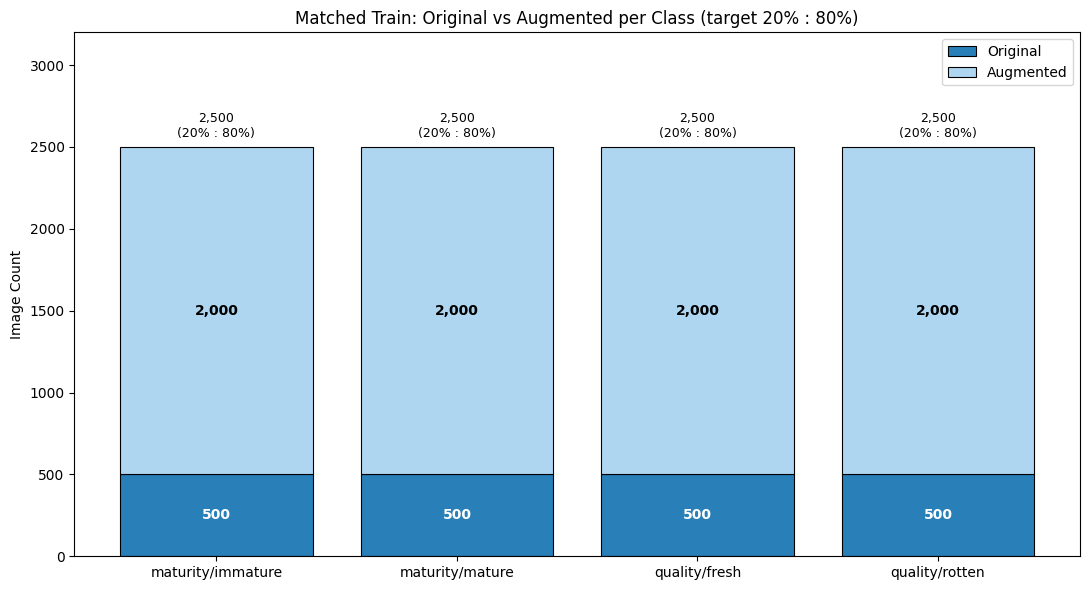


=== Original : Augmented per class ===
dataset_type       original  augment  total  orig_%  aug_%
maturity/immature       500     2000   2500    20.0   80.0
maturity/mature         500     2000   2500    20.0   80.0
quality/fresh           500     2000   2500    20.0   80.0
quality/rotten          500     2000   2500    20.0   80.0


In [7]:
pivot = (train_df.groupby(['task', 'class_label', 'dataset_type']).size()
         .unstack('dataset_type', fill_value=0)[['original', 'augment']])
pivot.index = [f'{t}/{c}' for t, c in pivot.index]

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(pivot.index, pivot['original'], color='#2980b9',
       edgecolor='black', linewidth=0.8, label='Original')
ax.bar(pivot.index, pivot['augment'], bottom=pivot['original'],
       color='#aed6f1', edgecolor='black', linewidth=0.8, label='Augmented')

# 세그먼트 안에 숫자, 위에 총합+비율
for i, (o, a) in enumerate(zip(pivot['original'], pivot['augment'])):
    ax.text(i, o/2, f'{o:,}', ha='center', va='center',
            fontweight='bold', color='white', fontsize=10)
    ax.text(i, o + a/2, f'{a:,}', ha='center', va='center',
            fontweight='bold', fontsize=10)
    total = o + a
    ax.text(i, total + 40,
            f'{total:,}\n({o/total*100:.0f}% : {a/total*100:.0f}%)',
            ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Image Count')
ax.set_title('Matched Train: Original vs Augmented per Class (target 20% : 80%)')
ax.set_ylim(0, 3200)
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '06_matched_train_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 표로도 출력
print()
print('=== Original : Augmented per class ===')
pivot_with_ratio = pivot.copy()
pivot_with_ratio['total'] = pivot.sum(axis=1)
pivot_with_ratio['orig_%'] = (pivot['original'] / pivot_with_ratio['total'] * 100).round(1)
pivot_with_ratio['aug_%'] = (pivot['augment'] / pivot_with_ratio['total'] * 100).round(1)
print(pivot_with_ratio.to_string())

## 5. 깨진 파일 검사 (매칭된 train만)

In [5]:
def is_valid(fp):
    try:
        with Image.open(fp) as img:
            img.verify()
        return True
    except Exception:
        return False

corrupted = []
for fp in tqdm(train_df['filepath'].tolist(), desc='Verifying'):
    if not is_valid(fp):
        corrupted.append(fp)

print(f'깨진 이미지: {len(corrupted)}장')
if corrupted:
    pd.DataFrame({'filepath': corrupted}).to_csv(TABLES_DIR / '04_corrupted_train.csv', index=False)
    train_df = train_df[~train_df['filepath'].isin(corrupted)].reset_index(drop=True)
    print(f'제외 후 train: {len(train_df):,}장')
else:
    print('✅ 모든 이미지 정상')

Verifying:   0%|          | 0/10000 [00:00<?, ?it/s]

깨진 이미지: 0장
✅ 모든 이미지 정상


## 6. 샘플 이미지 (각 클래스 4장)

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
classes = [('maturity', 'immature'), ('maturity', 'mature'),
           ('quality',  'fresh'),    ('quality',  'rotten')]
for row, (task, cls) in enumerate(classes):
    samples = train_df[(train_df['task'] == task) & (train_df['class_label'] == cls)].sample(n=4, random_state=SEED)
    for col, (_, r) in enumerate(samples.iterrows()):
        img = Image.open(r['filepath']).convert('RGB')
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{task}/{cls}", fontsize=10)
        axes[row, col].axis('off')
plt.tight_layout()
plt.savefig(RESULTS_DIR / '07_matched_samples.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. 저장

In [8]:
train_path = DATA_PROCESSED / 'train.csv'
train_df.to_csv(train_path, index=False)
print(f'✅ 저장: {train_path}  ({len(train_df):,} rows)')

# Subsampling 메타정보
meta = {
    'strategy': 'Option X: structure-matched (500 orig + 2000 aug per class)',
    'seed': SEED,
    'n_orig_per_class': N_ORIG,
    'n_aug_per_class': N_AUG,
    'total_samples': int(len(train_df)),
    'corrupted_excluded': len(corrupted),
    'counts_by_task_class': {f'{k[0]}/{k[1]}': int(v)
                              for k, v in train_df.groupby(['task','class_label']).size().to_dict().items()},
}
meta_path = DATA_PROCESSED / 'train_meta.json'
meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding='utf-8')
print(f'✅ 저장: {meta_path}')

✅ 저장: C:\Users\smin\IdeaProjects\tomato\data\processed\train.csv  (10,000 rows)
✅ 저장: C:\Users\smin\IdeaProjects\tomato\data\processed\train_meta.json


## 8. 요약

- ✅ Train 10,000장 매칭 완료 (4 클래스 × 2500장)
- ✅ 클래스 가중치 불필요 (1:1 균형)
- ✅ `train.csv` + `train_meta.json` 저장

### 다음 노트북
- `03_baseline_cv.ipynb`: 전통적 CV baseline (HOG+SVM 등)
- `04_single_task_maturity.ipynb`: CNN 싱글모델 (성숙도)
- `05_single_task_quality.ipynb`: CNN 싱글모델 (품질)
- `06_multitask.ipynb`: 멀티태스크 (masked loss)